## Cyclistic Bike Share-Analysis Member vs Casual Rider Behavior

### 1. Business Task

#### Business Problem
Cyclistic, a bike-share company, aims to increase its number of annual memberships, as these provide more consistent and predictable revenue compared to casual riders. Currently, a significant portion of users are casual riders, and the company seeks to convert more of these users into annual members.

#### Business Task
The task is to analyze Cyclistic’s historical trip data to identify how annual members and casual riders use the bike-share service differently. This includes examining differences in ride frequency, trip duration, time of use, and seasonal patterns.

#### Business Objective
The objective of this analysis is to uncover actionable insights into user behavior that can inform targeted marketing strategies designed to convert casual riders into annual members.

#### Key Analytical Question
How do annual members and casual riders use Cyclistic bikes differently?

### 2. Description of All Data Sources Used

#### Data Source Overview
The analysis uses Cyclistic’s historical trip data, which contains detailed records of individual bike rides over a 12-month period. The data has been made available by **Motivate International Inc.** under this [license](https://divvybikes.com/data-license-agreement).

The data is provided as multiple monthly CSV files, each containing trip-level information. These files were combined into a single dataset to enable comprehensive annual analysis and to capture seasonal patterns in rider behavior.

#### Dataset Structure

Each row in the dataset represents a single bike trip. The dataset includes the following key variables:
- `ride_id` – unique identifier for each trip
- `rideable_type` – type of bike used (e.g., classic, electric)
- `started_at` – timestamp when the trip began
- `ended_at` – timestamp when the trip ended
- `start_station_name` – name of the starting station
- `start_station_id` - unique identifier of the start station
- `end_station_name` – name of the ending station
- `end_station_id` - unique identifier of the end station
- `start_lat / start_lng` – geographic coordinates of the start location
- `end_lat / end_lng` – geographic coordinates of the end location
- `member_casual` – user type (annual member or casual rider)
  
The most critical variable for this analysis is member_casual, as it allows for segmentation and comparison between the two user groups.

#### Time Period Covered
The dataset spans a full 12-month period (March 2025 - February 2026), which enables analysis of:
- seasonal trends
- monthly usage patterns
- weekday vs weekend behavior
  
Using a full year of data ensures that the analysis captures both peak and off-peak usage periods.

### Data Limitations
While the dataset is rich in behavioral information, it has several limitations that should be acknowledged:
- **No demographic data**
    - The dataset does not include age, gender, income, or other demographic variables, limiting the ability to profile users beyond behavior.
- **No direct customer intent**
    - The data shows what users did, but not why they chose casual or annual usage.
- **Missing or incomplete station data**
    - Some records may contain null or inconsistent station names or coordinates.
- **Potential data quality issues**
    - Errors such as extremely short or unusually long ride durations may exist and require cleaning.
- **Geographic context is limited**
    - While coordinates are provided, the dataset does not explicitly label locations as residential, commercial, or tourist areas.

## 3. Data Cleaning and Manipulation

The raw Cyclistic trip data required extensive preprocessing to ensure accuracy, consistency, and suitability for analysis. All cleaning and transformation steps were performed primarily using SQL in MySQL Workbench.


#### 1. Data Type Standardization

Due to import errors, all fields were initially loaded as text. To enable accurate analysis:
- Date-time fields (started_at, ended_at) were converted into proper datetime formats using STR_TO_DATE
- Millisecond values were removed using SUBSTRING_INDEX to ensure compatibility with MySQL datetime parsing
- Latitude and longitude fields were validated and converted to numeric format (DECIMAL(10,6)) using conditional logic

This ensured all key fields were in appropriate formats for calculations and aggregation.

#### 2. Data Cleaning and Validation

To improve data quality, the following steps were applied:
- Removed records with missing or empty critical fields:
	- ride_id
	- started_at
	- ended_at
	- member_casual
- Trimmed whitespace from all text fields using TRIM()
- Validated numeric fields (latitude/longitude) using regular expressions before conversion
- Replaced missing station names and IDs with "Unknown" to retain records while maintaining consistency

These steps ensured that only valid and usable records were included in the analysis.

#### 3. Creation of Derived Variables

New variables were created to support behavioral analysis:

- `ride_length_minutes`<br>
    - Calculated using TIMESTAMPDIFF to measure trip duration<br>
- `ride_date and ride_time`<br>
    - Extracted from datetime fields for time-based analysis<br>
- `day_of_week and day_num`<br>
    - Enabled weekday vs. weekend comparisons<br>
- `month_name and month_num`<br>
    - Supported seasonal trend analysis<br>
- `hour_of_day`<br>
    - Allowed identification of peak riding hours

These derived fields were essential for answering the business question related to rider behavior patterns.


#### 4. Data Filtering

To ensure realistic and meaningful results:
- Removed rides with non-positive durations (ride_length_minutes <= 0)
- Excluded excessively long rides (> 1440 minutes) to eliminate outliers and potential data errors

This step improved the reliability of averages and trend analysis.


#### 5. Data Consolidation

All cleaning, transformation, and filtering steps were consolidated into a final structured table:

`cyclistic_trips_final`

This table:
- contains cleaned, validated, and enriched data
- serves as the single source for all subsequent analysis and visualization
- ensures consistency across all tools (SQL, Tableau, etc.)


**Summary**

The data cleaning and transformation process ensured that:
- all fields were correctly formatted and validated
- missing and inconsistent data were handled appropriately
- new variables were created to support time-based and behavioral analysis
- only high-quality, reliable data were used for insights

This rigorous preparation enabled accurate comparison between annual members and casual riders and supported all downstream analysis and visualizations.

### 4. Summary of Analysis

The objective of this analysis was to understand how annual members and casual riders use Cyclistic bikes differently in order to inform strategies for converting casual users into annual members.

Using the cleaned dataset, analysis was conducted across key dimensions, including ride frequency, trip duration, time of day, day of week, and seasonal trends.

#### 1. Ride Frequency and Composition

Annual members account for the majority of total rides, indicating consistent and frequent usage. In contrast, casual riders contribute a smaller share but show strong activity during specific periods.


#### 2. Ride Duration

Casual riders take significantly longer trips on average, while members have shorter, more time-efficient rides. This suggests that members use bikes for transportation, whereas casual riders use them for leisure.


#### 3. Time-of-Day Patterns

Members show clear peaks during morning and evening commute hours, while casual riders peak during midday and early evening. This reflects structured versus flexible usage patterns.


#### 4. Day-of-Week Trends

Member usage is highest on weekdays, while casual riders are more active on weekends, reinforcing the distinction between commuting and recreational use.


#### 5. Seasonal Trends

Casual ridership increases significantly during summer months, while member usage remains relatively stable throughout the year, indicating that casual riders are more influenced by seasonal conditions.


#### 6. Bike Type Preferences

Electric bikes are widely used across both groups, particularly among casual riders, suggesting a preference for convenience and ease of use.



**Overall Interpretation**

Annual members primarily use Cyclistic bikes for consistent, routine transportation, while casual riders use them for longer, leisure-oriented trips that vary by time and season. These differences highlight a clear opportunity to convert casual riders into members through targeted strategies aligned with their behavior.

### Visualization and Key Findings 

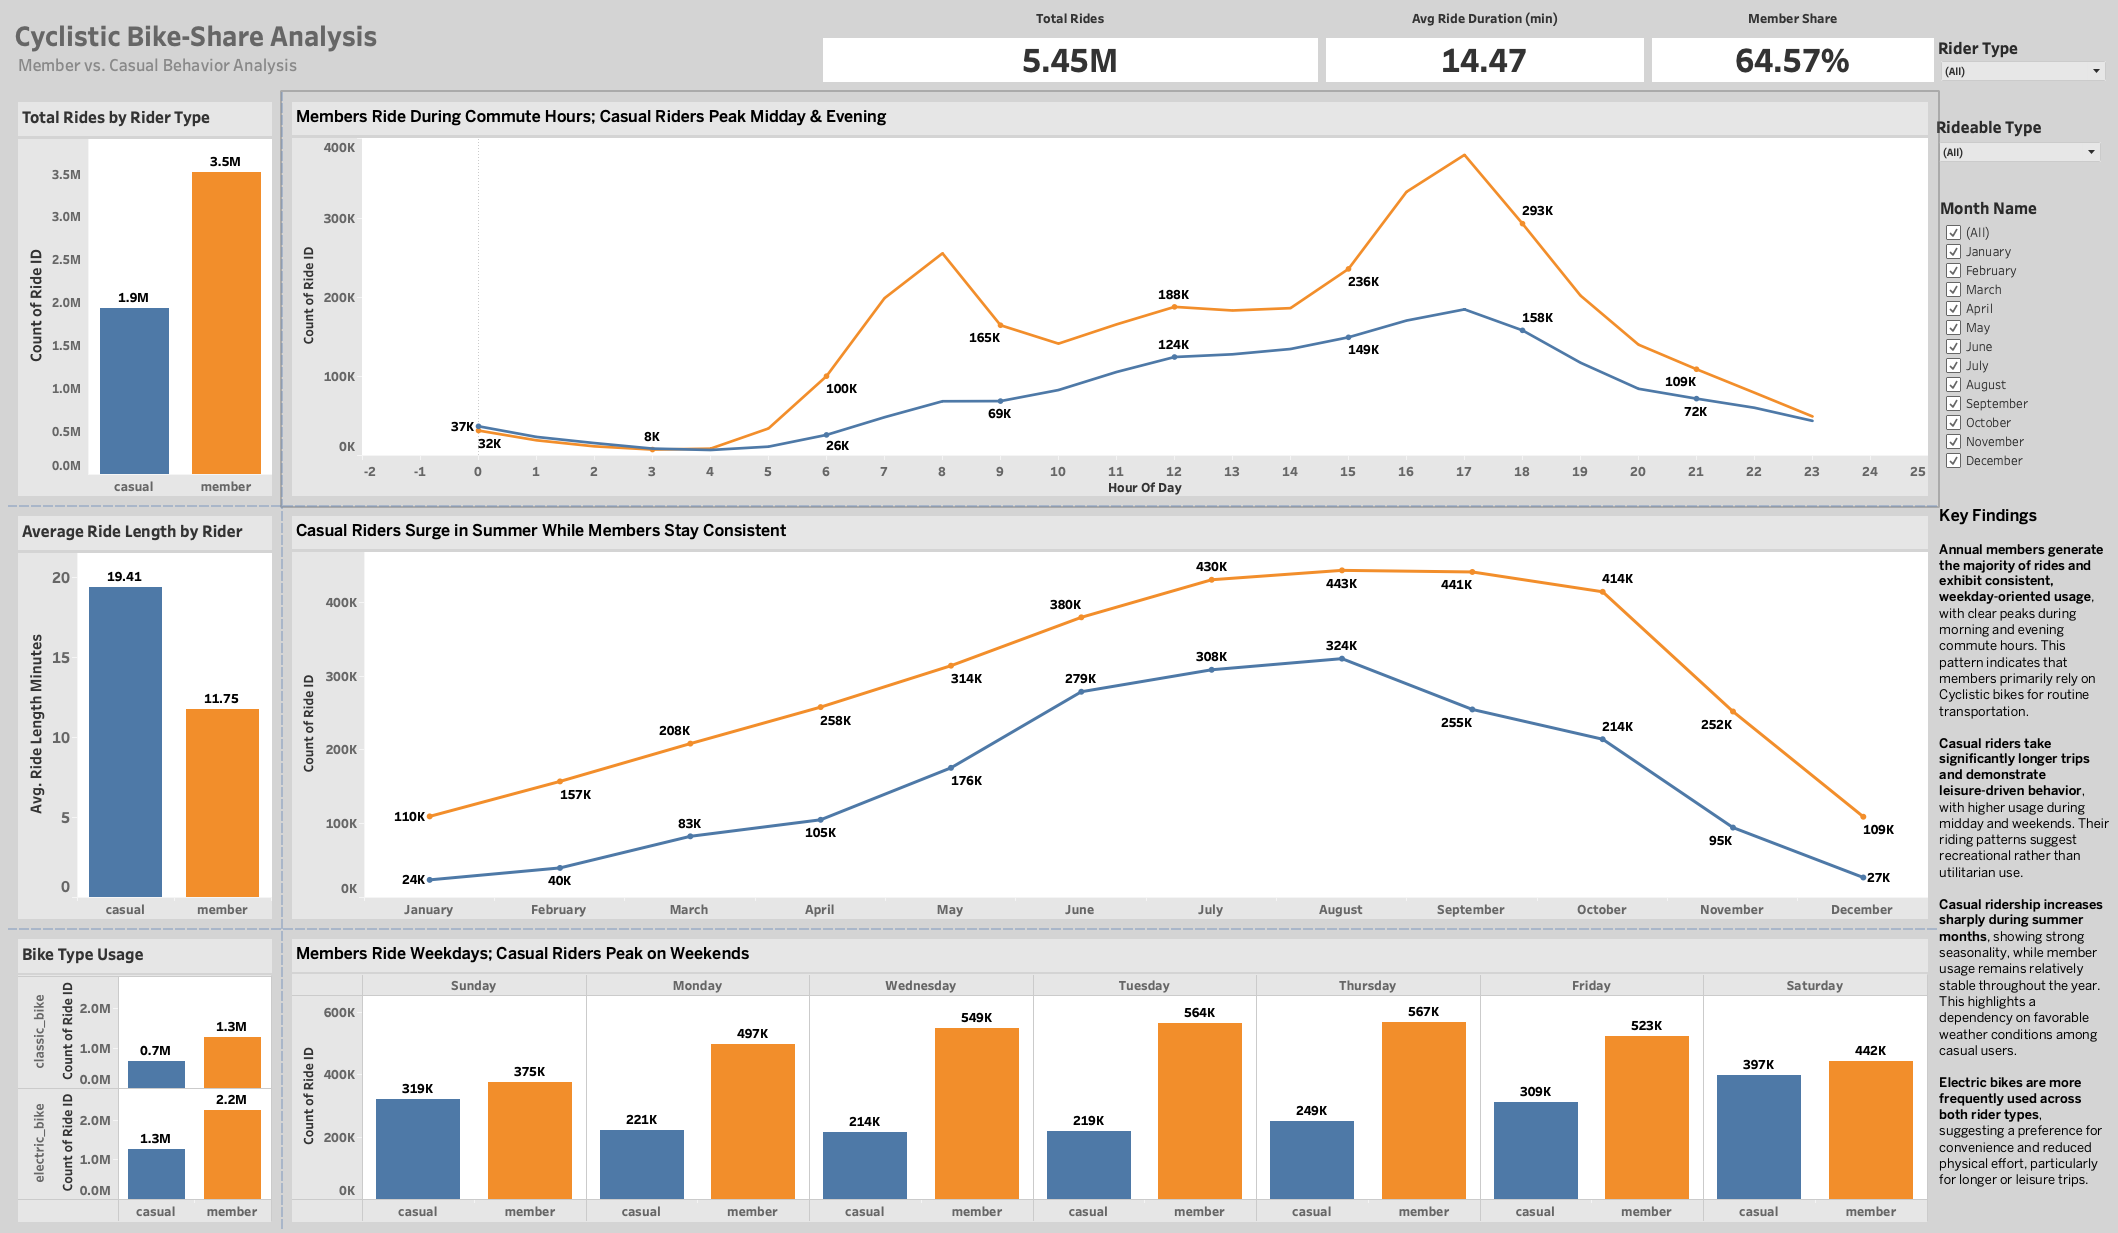

In [4]:
from IPython.display import Image, display

display(Image(filename='../images/dashboard.png'))

#### Key Findings

- **Annual members generate the majority of rides and exhibit consistent, weekday-oriented usage**, with clear peaks during morning and evening commute hours. This pattern indicates that members primarily rely on Cyclistic bikes for routine transportation.

- **Casual riders take significantly longer trips and demonstrate leisure-driven behavior**, with higher usage during midday and weekends. Their riding patterns suggest recreational rather than utilitarian use.

- **Casual ridership increases sharply during summer months**, showing strong seasonality, while member usage remains relatively stable throughout the year. This highlights a dependency on favorable weather conditions among casual users.

- **Electric bikes are more frequently used across both rider types**, suggesting a preference for convenience and reduced physical effort, particularly for longer or leisure trips. 

### 5. Top Three Recommendations

**1. Convert casual riders through targeted seasonal and weekend campaigns**

Casual riders demonstrate higher engagement during weekends and summer months, indicating strong but inconsistent usage. Cyclistic should implement targeted marketing campaigns during peak seasons, such as discounted trial memberships, weekend promotions, and limited-time offers, to encourage conversion.

**Rationale:**
Casual riders already exhibit high usage during specific periods, making them the most viable segment for membership growth.


**2. Position memberships as a reliable commuting solution**

Annual members show consistent weekday and peak-hour usage patterns, reflecting commuter behavior. Cyclistic should strengthen this positioning by promoting memberships as a cost-effective, convenient transportation option for daily commuting.

Recommended actions:
- Highlight cost savings compared to single rides
- Emphasize availability during peak hours
- Explore partnerships with employers or urban transit programs

**Rationale:**
Reinforcing existing behavior helps attract and retain users with similar commuting needs.


**3. Expand and promote electric bike usage**

Electric bikes are widely used, particularly among casual riders who take longer trips. Cyclistic should increase the availability of electric bikes in high-demand and recreational areas while promoting their convenience and accessibility.

Recommended actions:
- Allocate more electric bikes to high-traffic stations
- Highlight ease of use in marketing campaigns
- Include electric bike access in membership incentives

**Rationale:** Electric bikes reduce effort and increase accessibility, making them attractive for both leisure and commuting use cases.

**Conclusion**

These recommendations leverage observed behavioral differences between annual members and casual riders to support both membership growth and improved user experience, ultimately driving long-term engagement and revenue for Cyclistic.